In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import curve_fit
import sys
import os
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../../..'))

from source.include.components import *
from source.include.circuits import *
from source.include.helpers import *

from resonator_fitting.include import circle_fitting as cf
from resonator_fitting.include import resonance_fitting as rf
from resonator_fitting.include import all_resonances as ar


### Loading NIST Data

In [2]:
meas_flux = np.load('data/measured_flux_response.npz')
ibias = meas_flux['ibias'] #[all bias points]
dfs = meas_flux['freqs'] #[array of flux responses, each array of frequency shift at all bias points]


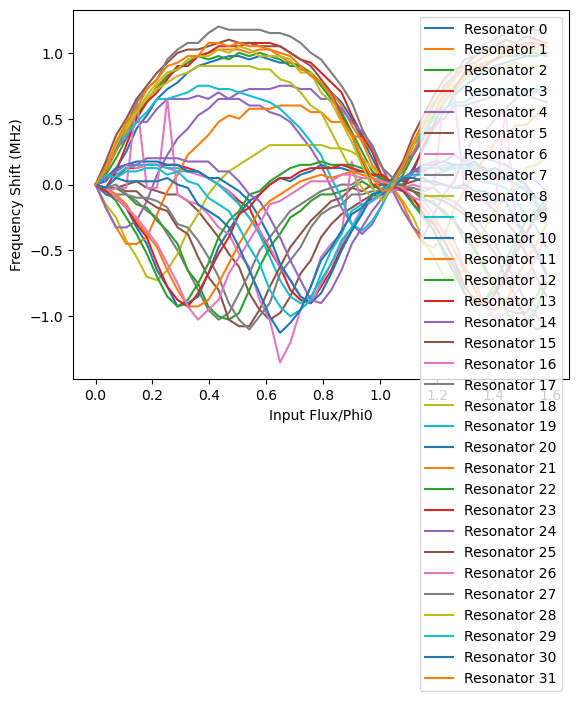

In [3]:
#number to show:
N = 32
for i in range(N):
    #plt.plot(ibias*1e6, 1e-6*dfs[i], label ="Resonator "+str(i))
    plt.plot(ibias*15e-12/Phi0, 1e-6*dfs[i], label ="Resonator "+str(i))

    plt.ylabel("Frequency Shift (MHz)")
    # plt.xlabel("Bias Current (uA)")
    plt.xlabel("Input Flux/Phi0")
    
plt.legend()
plt.show()
    

1.0443713324437212
A_32 (Harmonic 32): 0.9575 


/var/folders/5y/0rp23b8505l125t55yv9lq140000gn/T/ipykernel_89120/3840717421.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(harmonic_func, x, y, p0=p0)


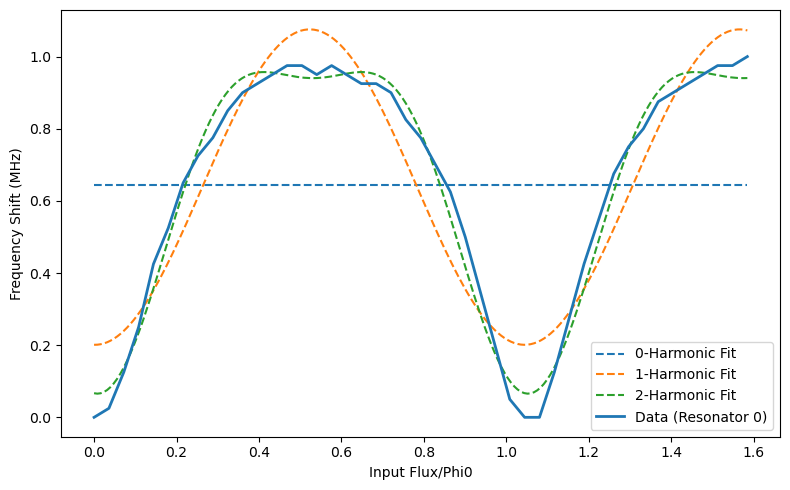

In [4]:
#Taking the first as an example
N = 0


phis = ibias*15e-12/Phi0
frs = dfs[N]


def fit_n_harmonics(x, y, n_harmonics=3):
    def harmonic_func(x, *params):
        y_offset = params[0]
        period = params[1]
        x_offset = params[2]

        result = np.full_like(x, y_offset, dtype=np.float64)

        for i in range(n_harmonics):
            A_k = params[3 + i]
            k = i + 1 
            result += A_k * np.cos(k * (2 * np.pi / period) * (x - x_offset))
            
        return result
    
    y_min, y_max = np.min(y), np.max(y)
    y_offset_guess = (y_max + y_min) / 2.0
    period_guess = 1.05  
    x_offset_guess = x[np.argmax(y)] 
    A1_guess = (y_max - y_min) / 2.0
    p0 = [y_offset_guess, period_guess, x_offset_guess, A1_guess] + [0.0] * (n_harmonics - 1)
    popt, pcov = curve_fit(harmonic_func, x, y, p0=p0)
    
    return harmonic_func, popt

plt.figure(figsize=(8, 5))
for n in range(3):

    fit_func, optimal_params = fit_n_harmonics(phis, frs, n_harmonics=n)

    y_offset_fit = optimal_params[0]
    period_fit = optimal_params[1]
    x_offset_fit = optimal_params[2]
    amplitudes_fit = optimal_params[3:]

    x_smooth = np.linspace(min(phis), max(phis), 200)
    plt.plot(x_smooth, 1e-6*fit_func(x_smooth, *optimal_params), 
            label=f"{n}-Harmonic Fit", linestyle='--')

print(period_fit)

print(f"A_{i+1} (Harmonic {i+1}): {1/period_fit:.4f} ")


plt.plot(phis, 1e-6*frs, label="Data (Resonator 0)", color='tab:blue', linewidth=2)

plt.xlabel("Input Flux/Phi0")
plt.ylabel("Frequency Shift (MHz)")
plt.legend()
plt.tight_layout()
plt.show()




[np.float64(0.9592515730542227), np.float64(0.9587351890743769), np.float64(0.9538867767733729), np.float64(0.950296558732138), np.float64(0.951497851998335), np.float64(0.9559946022065147), np.float64(0.9424667758324832), np.float64(0.9532235164616534), np.float64(0.9761781600216202), np.float64(0.9475777350295893), np.float64(0.9828826258670034), np.float64(0.9556593644852303), np.float64(0.9560431535726015), np.float64(0.9536817313231449), np.float64(0.9532376588131517), np.float64(0.9567867063706208), np.float64(0.9360242151623444), np.float64(0.9546554861742023), np.float64(0.9608673842415328), np.float64(0.953802989248453), np.float64(0.9427382547296713), np.float64(0.9735409379981138), np.float64(0.978370533139195), np.float64(0.9778655014283958), np.float64(0.9445084579277785), np.float64(0.9625859269878866), np.float64(0.9648847043469467), np.float64(0.9540035633526365), np.float64(0.9675721178034083), np.float64(0.9456804265639592), np.float64(0.955896765871714), np.float64(0

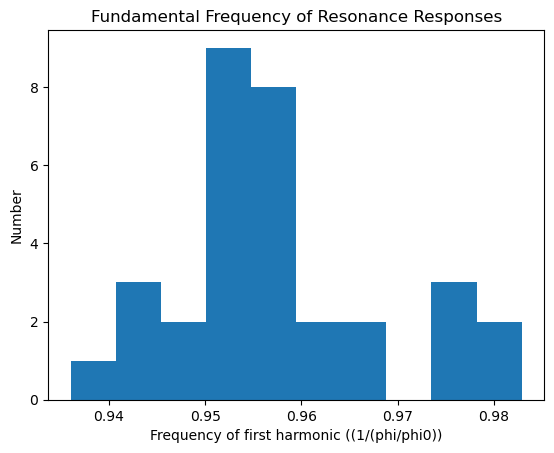

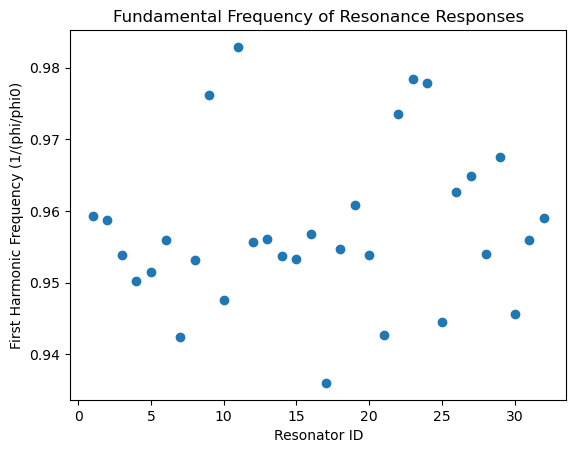

In [5]:
first_orders = []

for i in range(32):
    phis = ibias*15e-12/Phi0
    frs = dfs[i]

    def fit_n_harmonics(x, y, n_harmonics=3):
        def harmonic_func(x, *params):
            y_offset = params[0]
            period = params[1]
            x_offset = params[2]

            result = np.full_like(x, y_offset, dtype=np.float64)

            for i in range(n_harmonics):
                A_k = params[3 + i]
                k = i + 1 
                result += A_k * np.cos(k * (2 * np.pi / period) * (x - x_offset))
                
            return result
        
        y_min, y_max = np.min(y), np.max(y)
        y_offset_guess = (y_max + y_min) / 2.0
        period_guess = 1.05  
        x_offset_guess = x[np.argmax(y)] 
        A1_guess = (y_max - y_min) / 2.0
        p0 = [y_offset_guess, period_guess, x_offset_guess, A1_guess] + [0.0] * (n_harmonics - 1)
        popt, pcov = curve_fit(harmonic_func, x, y, p0=p0)
        
        return harmonic_func, popt

    fit_func, optimal_params = fit_n_harmonics(phis, frs, n_harmonics=1)

    y_offset_fit = optimal_params[0]
    period_fit = optimal_params[1]
    x_offset_fit = optimal_params[2]
    amplitudes_fit = optimal_params[3:]
    
    first_order = 1/period_fit
    
    first_orders.append(first_order)
    

print(first_orders)

ids = np.linspace(1,32,32)

plt.hist(first_orders)
plt.xlabel("Frequency of first harmonic ((1/(phi/phi0))")
plt.ylabel("Number")
plt.title("Fundamental Frequency of Resonance Responses")
plt.show()

plt.scatter(ids, first_orders)
plt.xlabel("Resonator ID")
plt.ylabel("First Harmonic Frequency (1/(phi/phi0)")
plt.title("Fundamental Frequency of Resonance Responses")
plt.show()

    
    




